# 模块说明

- **功能描述**：主要城市财政数据分析
- **输出结果**：基于清洗后数据 `city_budget_clean.csv` 的任务，实现以下分析目标，并将分析结果输出至`output`文件夹：
    - 简要分析计算每个城市在每个年度上的预算缺口及其占GDP比重情况， `income` 和 `expend` 的年度增长率情况
    - 列出2006、2010、2014、2018、2022年各年度 `gap_to_gdp`（预算缺口占GDP比重）最大和最小的城市。
    - 通过可视化分析整体趋势及极端城市表现。

# 一、设置与导入



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 定义路径
DATA_CLEAN = 'data_clean'
OUTPUT = 'output'
os.makedirs(OUTPUT, exist_ok=True)

# 读取清洗后的财政数据
df = pd.read_csv(os.path.join(DATA_CLEAN, 'city_budget_clean.csv'))
df['year'] = df['year'].astype(int)

print(f"数据年份范围：{df['year'].min()} - {df['year'].max()}")
print(f"城市数量：{df['city'].nunique()}")
print("\n数据前5行：")
df.head()

数据年份范围：2006 - 2024
城市数量：36

数据前5行：


,city,year,income,expend,deposit,gdp,gap,gap_to_gdp,income_growth,expend_growth,region_group,is_tier1
0,上海,2006,1576.0742,1795.5660,8730.000000,10825.4,219.4918,0.020276,NaN,NaN,长三角,True
1,上海,2007,2074.4792,2181.6780,8745.220000,13179.8,107.1988,0.008134,31.623194,21.503637,长三角,True
2,上海,2008,2358.7464,2593.9161,11464.150000,14877.1,235.1697,0.015807,13.703063,18.895460,长三角,True
3,上海,2009,2540.2975,2989.6500,13707.320000,16181.4,449.3525,0.027770,7.696932,15.256234,长三角,True
4,上海,2010,2873.5840,3302.8862,15650.239121,18319.6,429.3022,0.023434,13.119979,10.477354,长三角,True


# 二、任务1：计算预算缺口（gap）和 gap_to_gdp

## 1.1 任务描述
- 计算每个城市每年度的预算缺口 `gap = expend - income`（亿元）。
- 计算缺口占GDP的比重 `gap_to_gdp = gap / gdp`。
> `gap`和`gap_to_gdp`指标已运算完毕，故此处不再重复

本部分将验证它们的正确性，并展示其基本统计特征。

In [3]:
# 检查所需列是否存在
required_cols = ['gap', 'gap_to_gdp']
if all(col in df.columns for col in required_cols):
    print("✓ gap 和 gap_to_gdp 列已存在。")
else:
    print("✗ 缺少列，请检查数据清洗过程。")

# 查看缺失情况
print("\n缺失值统计：")
print(df[required_cols].isnull().sum())

# 基本统计描述
print("\n描述性统计：")
print(df[required_cols].describe().round(2))

✓ gap 和 gap_to_gdp 列已存在。

缺失值统计：
gap           0
gap_to_gdp    0
dtype: int64

描述性统计：
           gap  gap_to_gdp
count   684.00      684.00
mean    304.25        0.05
std     411.73        0.05
min    -107.98       -0.02
25%      72.85        0.02
50%     190.02        0.04
75%     344.99        0.06
max    3025.66        0.42


## 1.2 可视化分析

### 1.2.1 各年度 gap_to_gdp 箱线图与直方图
1. 箱线图观察缺口比重的整体分布及年度变化趋势。
2. 直方图展示所有年份合并的分布情况。

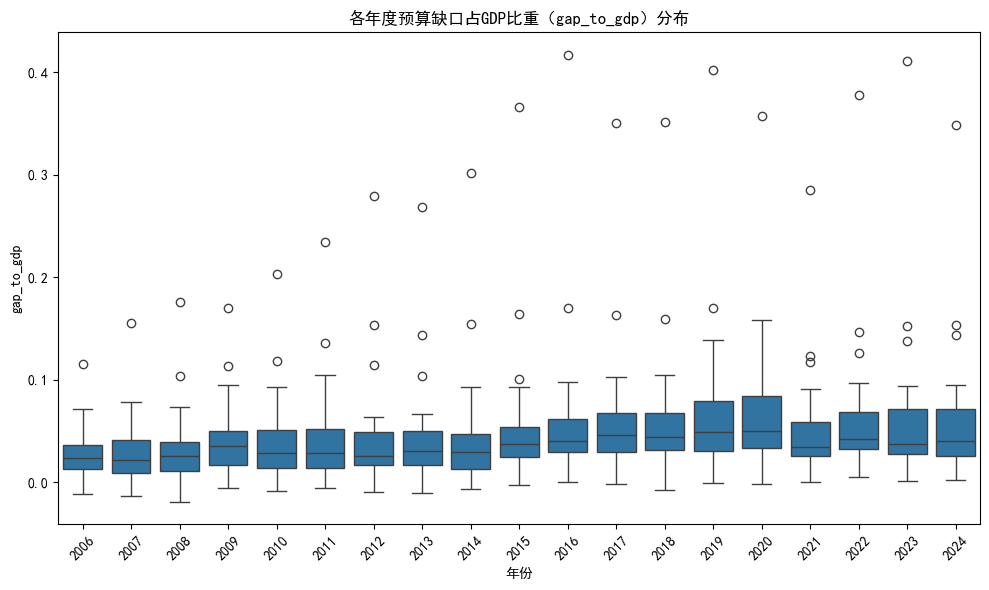

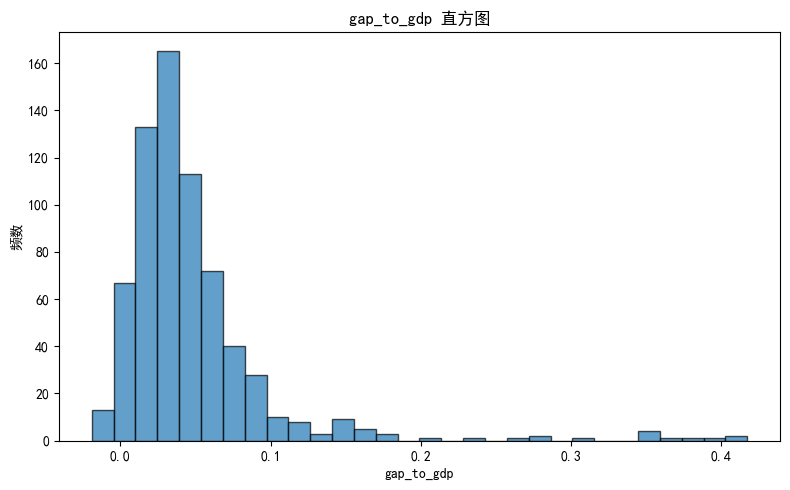

In [5]:
# 绘制箱线图
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='year', y='gap_to_gdp')
plt.xticks(rotation=45)
plt.title('各年度预算缺口占GDP比重（gap_to_gdp）分布')
plt.xlabel('年份')
plt.ylabel('gap_to_gdp')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'task1_boxplot.png'), dpi=150)
plt.show()

# 绘制直方图
plt.figure(figsize=(8, 5))
plt.hist(df['gap_to_gdp'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('gap_to_gdp')
plt.ylabel('频数')
plt.title('gap_to_gdp 直方图')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'task1_hist.png'), dpi=150)
plt.show()

### 1.2.2 剔除离群值后的数据可视化
考虑到拉萨等城市部分年份数据波动较大，为更细致观察集中情况，现使用**10~90%区间缩尾处理**后再做一次可视化进行观察

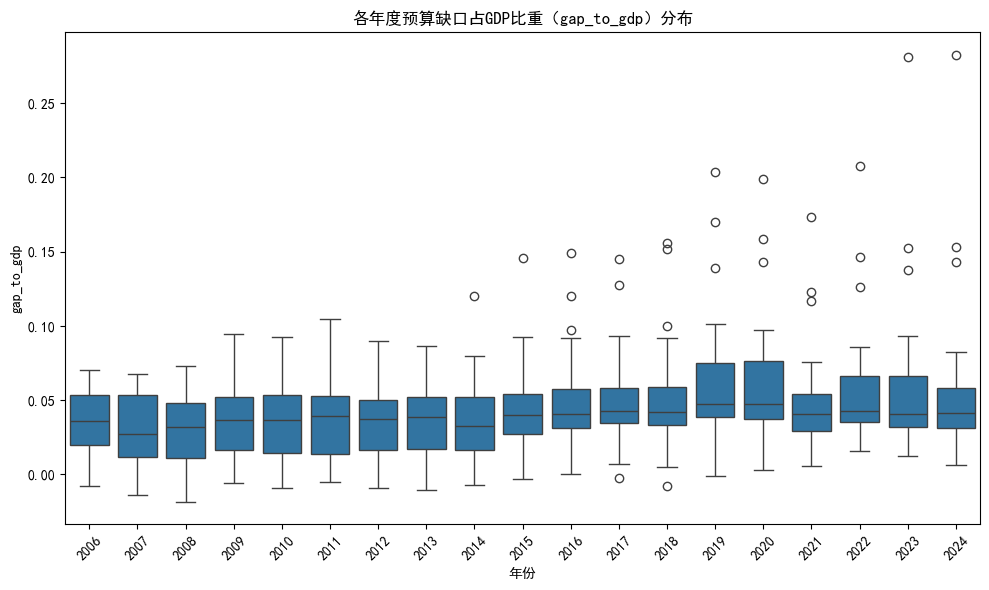

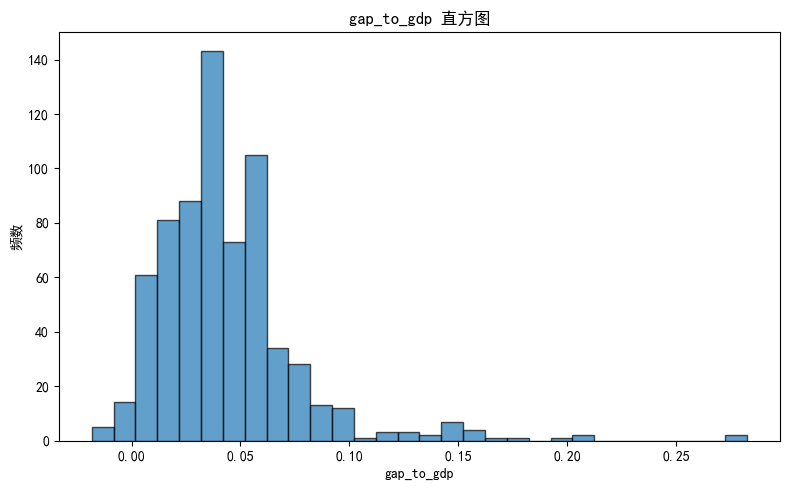

In [22]:
# 处理离群值
def series_winsorize(series, lower = 0.1, upper = 0.9):
    """处理离群值
    Args:
        series (pd.Series): 记得输入成series，别弄成df了
        lower: 下限
        upper: 上限
    Returns:
        series (pd.Series): 处理后的series
    """
    q_low = series.quantile(lower)  # 用quantile找出百分位值，而不是固定值
    q_up = series.quantile(upper)
    result = series.clip(lower=q_low, upper=q_up)
    return result

cols_need_winsorize = ['income', 'expend', 'gdp', 'deposit']
df_winsorized = df.copy()
for col in cols_need_winsorize:
    df_winsorized[col] = series_winsorize(df_winsorized[col])

# gap等指标再缩尾后重新计算
df_winsorized['gap'] = df_winsorized['expend'] - df_winsorized['income']
df_winsorized['gap_to_gdp'] = df_winsorized['gap'] / df_winsorized['gdp']
for col in ['income', 'expend']:
    df_winsorized[f'{col}_growth'] = df_winsorized.groupby('city')[col].pct_change() * 100

# 绘制箱线图
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_winsorized, x='year', y='gap_to_gdp')
plt.xticks(rotation=45)
plt.title('各年度预算缺口占GDP比重（gap_to_gdp）分布（缩尾处理后）')
plt.xlabel('年份')
plt.ylabel('gap_to_gdp')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'task1_boxplot_after_winsorized.png'), dpi=150)
plt.show()

# 绘制直方图
plt.figure(figsize=(8, 5))
plt.hist(df_winsorized['gap_to_gdp'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('gap_to_gdp')
plt.ylabel('频数')
plt.title('gap_to_gdp 直方图（缩尾处理后）')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'task1_hist_after_winsorized.png'), dpi=150)
plt.show()

## 1.3 简要分析
- 从箱线图（含离群值）可见，多数城市 gap_to_gdp 集中于0.0~0.1，但部分西部城市（如拉萨）个别年份超过0.3，显著拉高整体分布。
- 剔除极端值后（10%~90%缩尾），中位数从2006年的0.022稳步升至2022年的0.045，表明地方财政缺口占GDP比重长期呈扩大趋势。
- 值得注意的是，2020年缺口骤升至峰值（中位数0.060），可能与疫情冲击下支出刚性增长而收入下滑有关，2021年短暂回落，但2022年再次回升，显示财政压力仍存。

# 三、任务2：计算 income 和 expend 的年度增长率

## 2.1 任务描述
- 对每个城市，计算财政收入 `income` 和财政支出 `expend` 的年度增长率（百分比）。
- 计算公式：`增长率 = (当年值 - 上年值) / 上年值 × 100`。

增长率已在清洗阶段计算，本部分将验证其存在性并展示统计特征。

In [7]:
growth_cols = ['income_growth', 'expend_growth']
if all(col in df.columns for col in growth_cols):
    print("✓ 增长率列已存在。")
else:
    print("✗ 增长率列缺失，请检查数据清洗。")

print("\n缺失值统计（首年无增长率）：")
print(df[growth_cols].isnull().sum())

print("\n描述性统计（剔除NaN后）：")
print(df[growth_cols].describe().round(2))

✓ 增长率列已存在。

缺失值统计（首年无增长率）：
income_growth    36
expend_growth    36
dtype: int64

描述性统计（剔除NaN后）：
       income_growth  expend_growth
count         648.00         648.00
mean           12.66          13.30
std            15.94          12.55
min           -36.99         -21.85
25%             3.65           4.33
50%            10.91          12.41
75%            19.50          20.46
max           172.51          65.40


## 2.2 可视化分析

### 2.2.1 收入增长率分布箱线图与直方图

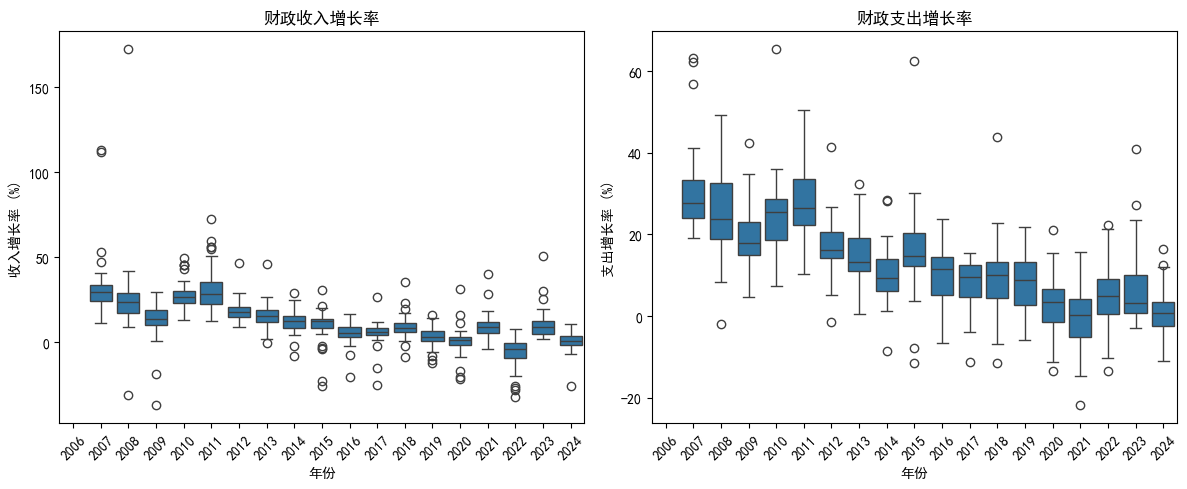

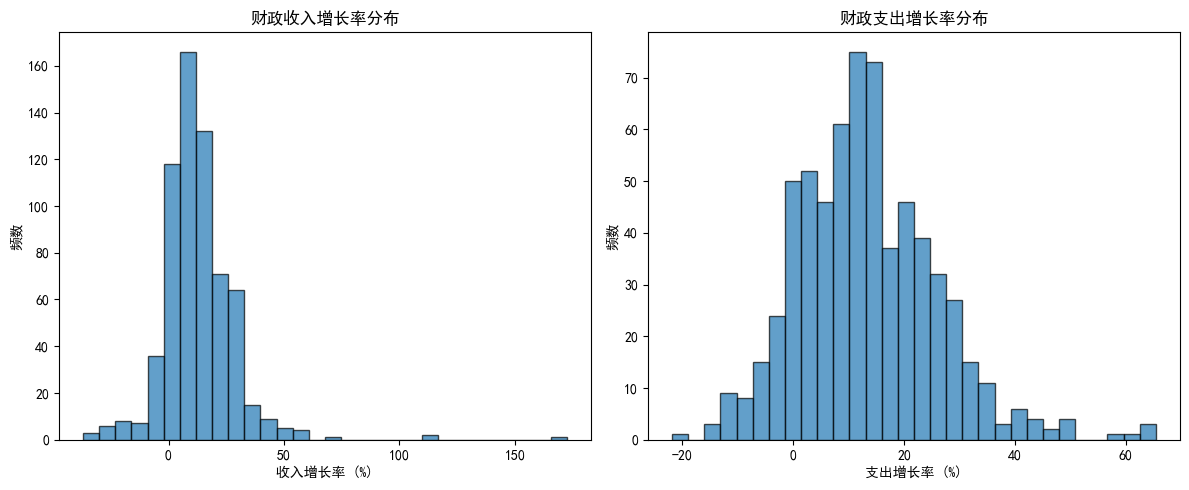

In [10]:
# 绘制箱线图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='year', y='income_growth')
plt.xlabel('年份')
plt.ylabel('收入增长率 (%)')
plt.xticks(rotation=45)
plt.title('财政收入增长率')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='year', y='expend_growth')
plt.xlabel('年份')
plt.ylabel('支出增长率 (%)')
plt.xticks(rotation=45)
plt.title('财政支出增长率')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'task2_growth_boxplot.png'), dpi=150)
plt.show()

# 绘制直方图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['income_growth'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('收入增长率 (%)')
plt.ylabel('频数')
plt.title('财政收入增长率分布')

plt.subplot(1, 2, 2)
plt.hist(df['expend_growth'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('支出增长率 (%)')
plt.ylabel('频数')
plt.title('财政支出增长率分布')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'task2_growth_hist.png'), dpi=150)
plt.show()

### 2.2.2 缩尾处理后的可视化

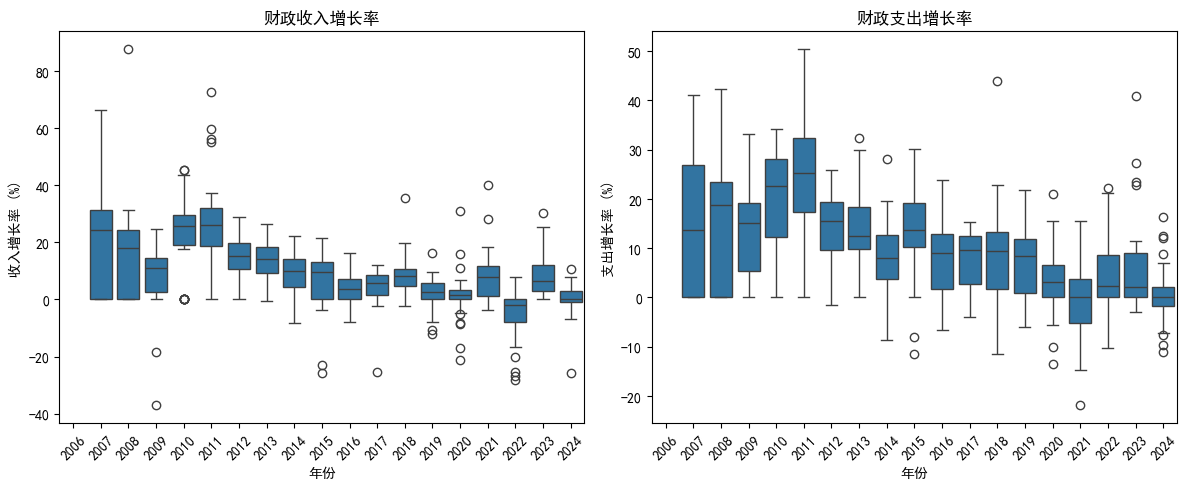

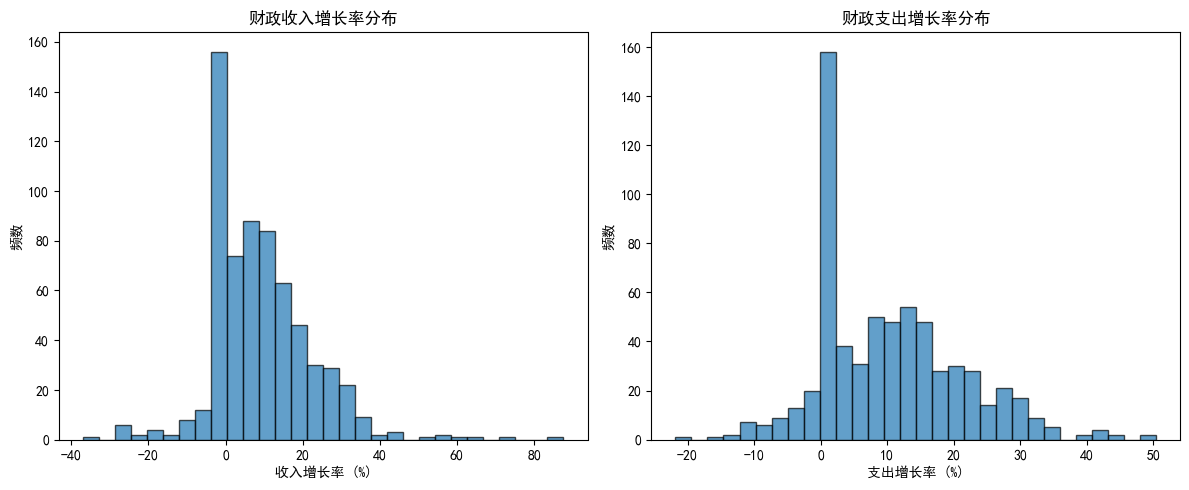

In [23]:
# 前面1.2.2已经算过了，这里直接调用即可

# 绘制箱线图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_winsorized, x='year', y='income_growth')
plt.xlabel('年份')
plt.ylabel('收入增长率 (%)')
plt.xticks(rotation=45)
plt.title('财政收入增长率')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_winsorized, x='year', y='expend_growth')
plt.xlabel('年份')
plt.ylabel('支出增长率 (%)')
plt.xticks(rotation=45)
plt.title('财政支出增长率')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'task2_growth_boxplot_after_winsorized.png'), dpi=150)
plt.show()

# 绘制直方图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_winsorized['income_growth'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('收入增长率 (%)')
plt.ylabel('频数')
plt.title('财政收入增长率分布')

plt.subplot(1, 2, 2)
plt.hist(df_winsorized['expend_growth'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('支出增长率 (%)')
plt.ylabel('频数')
plt.title('财政支出增长率分布')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'task2_growth_hist_after_winsorized.png'), dpi=150)
plt.show()

## 2.3 简要分析
- 原始数据中，收入增长率标准差（15.9%）高于支出增长率（12.6%），主要由于个别城市收入剧烈波动（如资源型城市）。
- 缩尾处理后两者波动接近（收入10.5%，支出9.2%），表明正常情况下收支增速同步性较强。
- 2009年和2020年收入增长率显著为负，支出增长率则保持正增长，体现财政的稳定器功能。
- 支出增长率的年度间差异略小于收入，反映支出刚性特征。

# 四、任务3：2006、2010、2014、2018、2022 年 `gap_to_gdp` 极值城市

## 3.1 任务描述
- 筛选目标年份：2006、2010、2014、2018、2022。
- 对每个年份，找出 `gap_to_gdp` 最大和最小的城市及其数值。
- 以表格形式呈现结果。

In [14]:
target_years = [2006, 2010, 2014, 2018, 2022]
df_target = df[df['year'].isin(target_years)].copy()

summary = []
for year in target_years:
    data = df_target[df_target['year'] == year].copy()
    # 最大值
    max_idx = data['gap_to_gdp'].idxmax()
    max_city = data.loc[max_idx, 'city']
    max_val = data['gap_to_gdp'].max()
    # 最小值
    min_idx = data['gap_to_gdp'].idxmin()
    min_city = data.loc[min_idx, 'city']
    min_val = data['gap_to_gdp'].min()
    summary.append({
        '年份': year,
        '最大城市': max_city,
        '最大值': round(max_val, 4),
        '最小城市': min_city,
        '最小值': round(min_val, 4)
    })

df_summary = pd.DataFrame(summary).round(4)
df_summary


,年份,最大城市,最大值,最小城市,最小值
0,2006,拉萨,0.1152,乌鲁木齐,-0.0115
1,2010,拉萨,0.2031,杭州,-0.0092
2,2014,拉萨,0.3013,杭州,-0.0072
3,2018,拉萨,0.3514,杭州,-0.0080
4,2022,拉萨,0.3784,杭州,0.0049


In [15]:
# 保存表格
df_summary.to_excel(os.path.join(OUTPUT, 'task3_extremes.xlsx'), index=False)
print(f"表格已保存至 {OUTPUT}/task3_extremes.xlsx")

表格已保存至 output/task3_extremes.xlsx


## 3.2 可视化：极端城市历年 `gap_to_gdp` 变化趋势

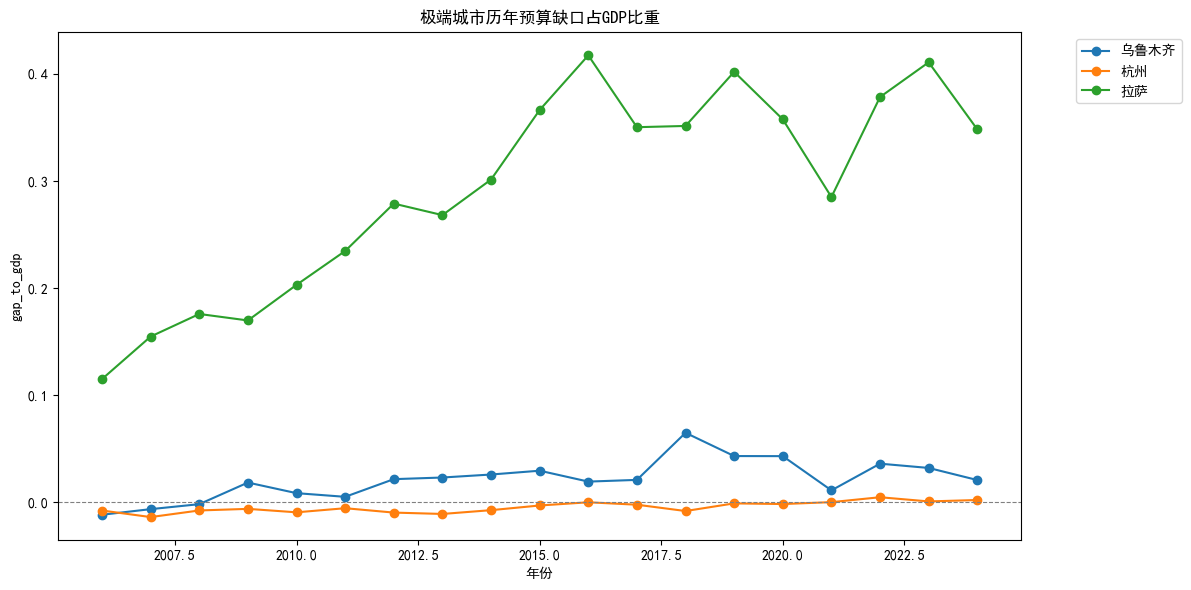

In [16]:
# 获取所有极端城市（去重）
extreme_cities = set(df_summary['最大城市']) | set(df_summary['最小城市'])
df_extreme = df[df['city'].isin(extreme_cities)].copy()

plt.figure(figsize=(12, 6))
for city in extreme_cities:
    city_data = df_extreme[df_extreme['city'] == city].sort_values('year')
    plt.plot(city_data['year'], city_data['gap_to_gdp'], marker='o', label=city)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('年份')
plt.ylabel('gap_to_gdp')
plt.title('极端城市历年预算缺口占GDP比重')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'task3_trend.png'), dpi=150)
plt.show()

## 3.3 简要分析
- 目标年份中，**拉萨**始终为 gap_to_gdp 最大城市，且数值从0.115持续攀升至0.378，财政缺口相对GDP规模快速扩大，反映出西部地区对上级转移支付的依赖不断增强。
- 相反，**杭州**连续多年为最小城市，甚至在2010—2018年间出现财政盈余，体现了发达城市强劲的经济造血能力。
- 趋势图显示，拉萨的缺口比重自2014年后加速上升，而杭州始终稳定在零值附近，两类城市财政健康状况分化加剧。

# 五、综合结论

通过以上三个任务的分析，可以得出以下主要结论：

1. **财政缺口普遍存在且逐年扩大**：2006—2022年间，多数城市财政支出持续超过收入，`gap_to_gdp`中位数从约0.02升至0.045，显示地方财政压力加剧。
2. **增长率波动受经济周期影响**：2009年和2020年收入增长率大幅下滑，支出增长率保持韧性，反映财政逆周期调节作用；支出波动略小于收入，体现支出刚性。
3. **极端城市分化显著**：拉萨等西部城市缺口比重持续高企且攀升，杭州等东部城市长期保持平衡甚至盈余，区域财政自给能力差异悬殊。
4. **经济规模与财政健康度相**：从极端城市看，GDP较高的城市（如杭州）往往缺口较小或盈余，而GDP较低的城市（如拉萨）缺口较大，这可能与税基规模、产业结构及转移支付制度有关。未来可进一步探讨财政转移支付的精准性与地方财政可持续性。